Assignment 4 — Training a DCGAN on Fashion-MNIST
Objective



To understand how a Deep Convolutional Generative Adversarial Network (DCGAN) is trained using the Fashion-MNIST dataset and how the Generator and Discriminator improve during training.




In [4]:
# Install PyTorch if required
!pip install torch torchvision matplotlib -q

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [5]:
# Check whether GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Parameters
batch_size = 128
image_size = 64
latent_dim = 100
num_epochs = 30
learning_rate = 0.0002
beta1 = 0.5

# Create folder to save generated images
os.makedirs("generated_images", exist_ok=True)

Using device: cpu


In [6]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of training images:", len(dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.28MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.1MB/s]


Number of training images: 60000


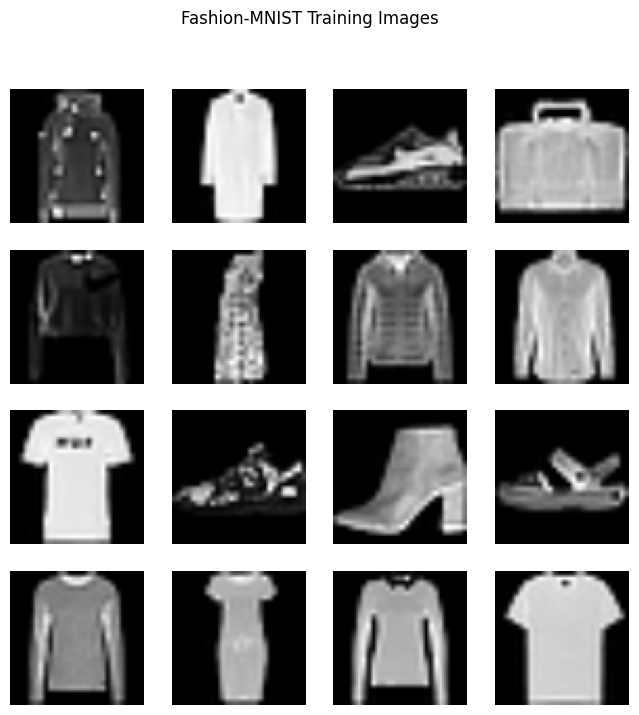

In [7]:
images, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Fashion-MNIST Training Images")
plt.show()

In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 x 1 x 1 -> 512 x 4 x 4
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 512 x 4 x 4 -> 256 x 8 x 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 8 x 8 -> 128 x 16 x 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 16 x 16 -> 64 x 32 x 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 32 x 32 -> 1 x 64 x 64
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 1 x 64 x 64 -> 64 x 32 x 32
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32 -> 128 x 16 x 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16 -> 256 x 8 x 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 x 8 x 8 -> 512 x 4 x 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 512 x 4 x 4 -> 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

In [10]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [11]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [12]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

In [13]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

In [ ]:
G_losses = []
D_losses = []

for epoch in range(1, num_epochs + 1):

    for batch_idx, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size_current = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------

        discriminator.zero_grad()

        # Real images
        real_labels = torch.ones(batch_size_current, device=device)

        output_real = discriminator(real_images)

        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(batch_size_current, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)

        fake_labels = torch.zeros(batch_size_current, device=device)

        output_fake = discriminator(fake_images.detach())

        loss_fake = criterion(output_fake, fake_labels)

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()


        # -------------------------
        # Train Generator
        # -------------------------

        generator.zero_grad()

        # Generator wants discriminator
        # to classify fake images as real
        generator_labels = torch.ones(batch_size_current, device=device)

        output = discriminator(fake_images)

        loss_G = criterion(output, generator_labels)

        loss_G.backward()
        optimizer_G.step()


        # Store losses
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())


    # Generate images after every 5 epochs
    if epoch % 5 == 0:

        with torch.no_grad():
            generated = generator(fixed_noise).detach().cpu()

        # Save 4 x 4 grid
        filename = f"generated_images/epoch_{epoch}.png"

        save_image(
            generated,
            filename,
            nrow=4,
            normalize=True
        )

        print(
            f"Epoch [{epoch}/{num_epochs}] "
            f"Generator Loss: {loss_G.item():.4f} "
            f"Discriminator Loss: {loss_D.item():.4f}"
        )

In [ ]:
epochs_to_show = [5, 10, 15, 20, 25, 30]

plt.figure(figsize=(12, 8))

for i, epoch in enumerate(epochs_to_show):

    image = plt.imread(f"generated_images/epoch_{epoch}.png")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Epoch {epoch}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss During Training")

plt.legend()
plt.grid()

plt.show()

In [ ]:
for epoch in epochs_to_show:

    image = plt.imread(f"generated_images/epoch_{epoch}.png")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"Generated Fashion-MNIST Images - Epoch {epoch}")
    plt.axis("off")
    plt.show()

In [ ]:
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

print("Models saved successfully!")

OBSERVATION

The generated images were unclear and noisy in the early epochs. As training continued, the images became clearer and clothing shapes started appearing. By later epochs, the Generator produced more recognizable images. The losses changed during training as the Generator and Discriminator competed with each other.


CONCLUSION

The DCGAN successfully learned to generate clothing like images from Fashion-MNIST. The quality of the generated images improved with training, showing how the Generator and Discriminator learn together.
